<a href="https://colab.research.google.com/github/TarfaGaida/A-B-Testng/blob/main/A_B_Testing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Library

In [ ]:
import numpy as np #library untuk matematika
import pandas as pd #library untuk dataframe
import seaborn as sns #library untuk visualisasi
import matplotlib.pyplot as plt

# One sample T-test

Digunakan untuk membandingkan hasil dari eksperimen yang tidak memiliki benchmark sebelumnya

In [ ]:
#import dataset from google drive
from google.colab import drive
drive.mount('/content/drive/')
data_path = '/content/drive/MyDrive/Data Science/Day 26_A B Testing/Assignment/'


Mounted at /content/drive/


In [ ]:
file_name = data_path +'ab_data.csv'
df = pd.read_csv(file_name)
df.head()


,user_id,timestamp,group,landing_page,converted
0,851104,2017-01-21 22:11:48.556739,control,old_page,0
1,804228,2017-01-12 08:01:45.159739,control,old_page,0
2,661590,2017-01-11 16:55:06.154213,treatment,new_page,0
3,853541,2017-01-08 18:28:03.143765,treatment,new_page,0
4,864975,2017-01-21 01:52:26.210827,control,old_page,1


In [ ]:
df.shape


(294478, 5)

In [ ]:
df.nunique()

,0
user_id,290584
timestamp,294478
group,2
landing_page,2
converted,2


In [ ]:
df.isna().sum()

,0
user_id,0
timestamp,0
group,0
landing_page,0
converted,0


*  user_id: unique id of the user who came to the website
*  timestamp: timestamp that the user came to the page
*  group: whether the user in treatment group or control group
*  landing_page: whether the user saw the old page or new page
*  converted: whether the user converted to a paid user. 1 means converted, 0 means not converted.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294478 entries, 0 to 294477
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   user_id       294478 non-null  int64 
 1   timestamp     294478 non-null  object
 2   group         294478 non-null  object
 3   landing_page  294478 non-null  object
 4   converted     294478 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 11.2+ MB


# Hipotesis
  Compare the conversion rates between the control group (old page) and the treatment group (new page).
* Null Hypothesis (H0): The conversion rate is the same for both groups.
* Alternative Hypothesis (𝐻1): The conversion rate differs between the groups.

In [ ]:
#Data Clean

# Ensure that each group matches the expected landing page
# Control -> old_page; Treatment -> new_page
clean_df = df[(df['group'] == 'control') & (df['landing_page'] == 'old_page') |
                    (df['group'] == 'treatment') & (df['landing_page'] == 'new_page')]

clean_df.head()


,user_id,timestamp,group,landing_page,converted
0,851104,2017-01-21 22:11:48.556739,control,old_page,0
1,804228,2017-01-12 08:01:45.159739,control,old_page,0
2,661590,2017-01-11 16:55:06.154213,treatment,new_page,0
3,853541,2017-01-08 18:28:03.143765,treatment,new_page,0
4,864975,2017-01-21 01:52:26.210827,control,old_page,1


In [ ]:
count_convertion = clean_df.groupby('group')['converted'].value_counts()
count_convertion

group      converted
control    0            127785
           1             17489
treatment  0            128047
           1             17264
Name: count, dtype: int64

In [ ]:
# Calculate conversion rates for each group
conversion_rates = clean_df.groupby('group')['converted'].mean()
clean_df.shape, conversion_rates

((290585, 5),
 group
 control      0.120386
 treatment    0.118807
 Name: converted, dtype: float64)

The dataset now contains 290,585 rows

Conversion rates:
* Control group (old page): 12.04%
* Treatment group (new page): 11.88%

In [ ]:
#Convertion Rate Difference
Rate_diff = conversion_rates[1] - conversion_rates[0]
Rate_diff

<ipython-input-17-0cf99c8f0319>:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  Rate_diff = conversion_rates[1] - conversion_rates[0]


-0.0015790565976871451

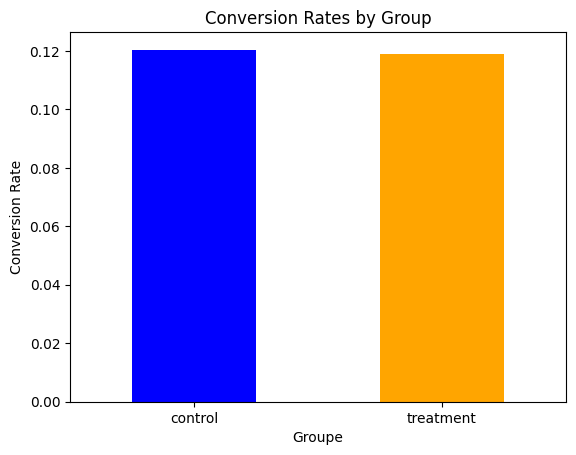

In [ ]:

conversion_rates.plot(kind='bar', color=['blue', 'orange'])
plt.title('Conversion Rates by Group')
plt.xlabel('Groupe')
plt.ylabel('Conversion Rate')
plt.xticks(rotation=0)
plt.show()


In [ ]:
from statsmodels.stats.proportion import proportions_ztest


In [ ]:
# Number of conversions and total observations in each group
control_conversion = clean_df[clean_df['group'] == 'control']['converted'].sum()
total_control = clean_df[clean_df['group'] == 'control'].shape[0]


treatment_conversion = clean_df[clean_df['group'] == 'treatment']['converted'].sum()
total_treatment = clean_df[clean_df['group'] == 'treatment'].shape[0]

total_control, total_treatment

(145274, 145311)

In [ ]:
# Perform a two-tailed z-test
control = [control_conversion, treatment_conversion]
nobs = [total_control, total_treatment]

z_stat, p_value = proportions_ztest(control, nobs)

z_stat, p_value

(1.3116075339133115, 0.18965258971881804)

The results of the z-test are as follows:

* Z-statistic: 1.31
* P-value: 0.1897

In [ ]:
if p_value < 0.05:
  print("H0 ditolak, tidak ada perbedaan conversion rate sebelum  dan sesudah ")
else:
  print("H0 diterima, terdapat perbedaan conversion rate sebelum  dan sesudah")


H0 diterima, terdapat perbedaan conversion rate sebelum  dan sesudah


Z-statistic = 1.31: Nilai Z menunjukkan bahwa perbedaan proporsi teramati berada 1.31 standar deviasi dari nol (hipotesis nol).

P-value = 0.1897: Probabilitas mendapatkan hasil seperti ini (atau lebih ekstrem) jika hipotesis nol benar.

Karena P-value (0.1897) > 0.05, kita gagal menolak hipotesis nol.

Artinya:

Tidak ada perbedaan signifikan secara statistik antara tingkat konversi grup kontrol dan grup perlakuan.
Kedua halaman tampak serupa secara statistik dalam hal mengonversi pengguna.